# Задание 1
- Построить график произвольной функции из `pywt.data`.

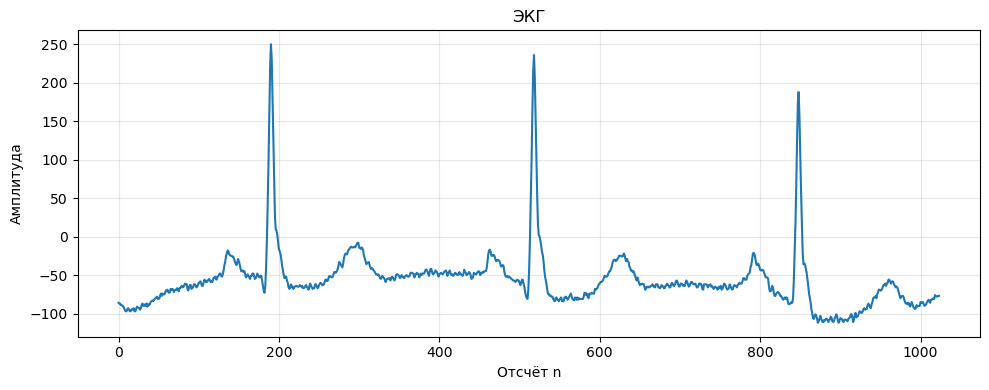

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

signal = pywt.data.ecg()

t = np.arange(len(signal))

plt.figure(figsize=(10, 4))
plt.plot(t, signal, linewidth=1.5)
plt.title('ЭКГ')
plt.xlabel('Отсчёт n')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.tight_layout()

- Построить скейлограмму.

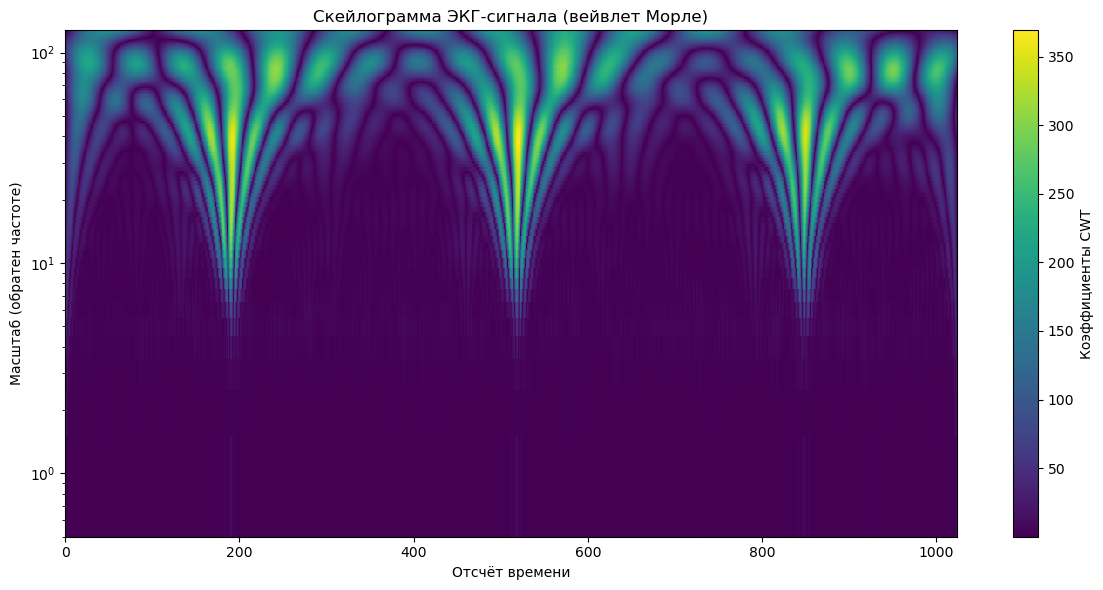

In [ ]:
wavelet = 'morl'              # вейвлет Морле
scales = np.arange(1, 128)    # масштабные коэффициенты (чем больше — тем ниже частота)

coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1.0)

plt.figure(figsize=(12, 6))

plt.pcolormesh(t, scales, np.abs(coefficients), shading='auto', cmap='viridis')
plt.colorbar(label='Коэффициенты CWT')

plt.xlabel('Отсчёт времени')
plt.ylabel('Масштаб (обратен частоте)')
plt.title('Скейлограмма ЭКГ-сигнала (вейвлет Морле)')
plt.yscale('log')
plt.tight_layout()

- Построить трехмерную поверхность двухпараметрического спектра $W(a,b)$. Как [здесь](https://habr.com/ru/articles/449646/).

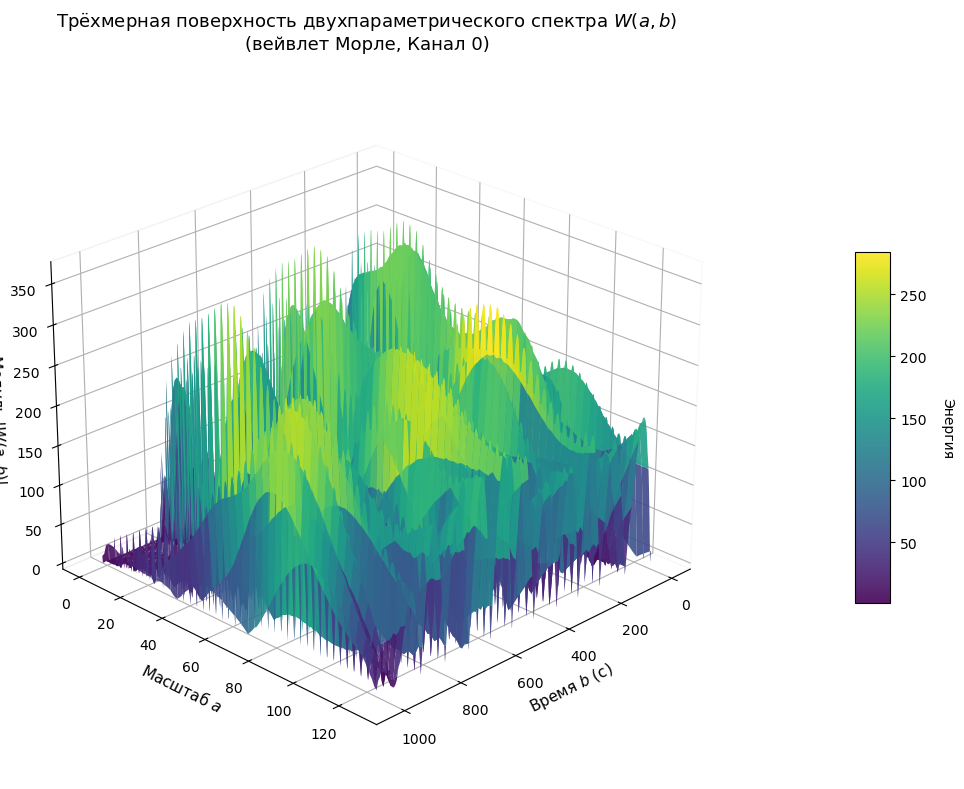

In [ ]:
b_axis = t  # translation parameter (время)
a_axis = scales  # scale parameter
B, A = np.meshgrid(b_axis, a_axis)  # матрицы для поверхности
Z = np.abs(coefficients)  # модуль коэффициентов = высота поверхности

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(B, A, Z, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('Время $b$ (с)', fontsize=11)
ax.set_ylabel('Масштаб $a$', fontsize=11)
ax.set_zlabel('Модуль $|W(a,b)|$', fontsize=11)
ax.set_title('Трёхмерная поверхность двухпараметрического спектра $W(a,b)$\n(вейвлет Морле, Канал 0)', fontsize=13, pad=20)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Энергия', rotation=270, labelpad=20)

ax.view_init(elev=25, azim=45)

ax.grid(True, alpha=0.3)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()

- Построить плоскость $ab$ с цветовыми областями вейвлет-преобразования.

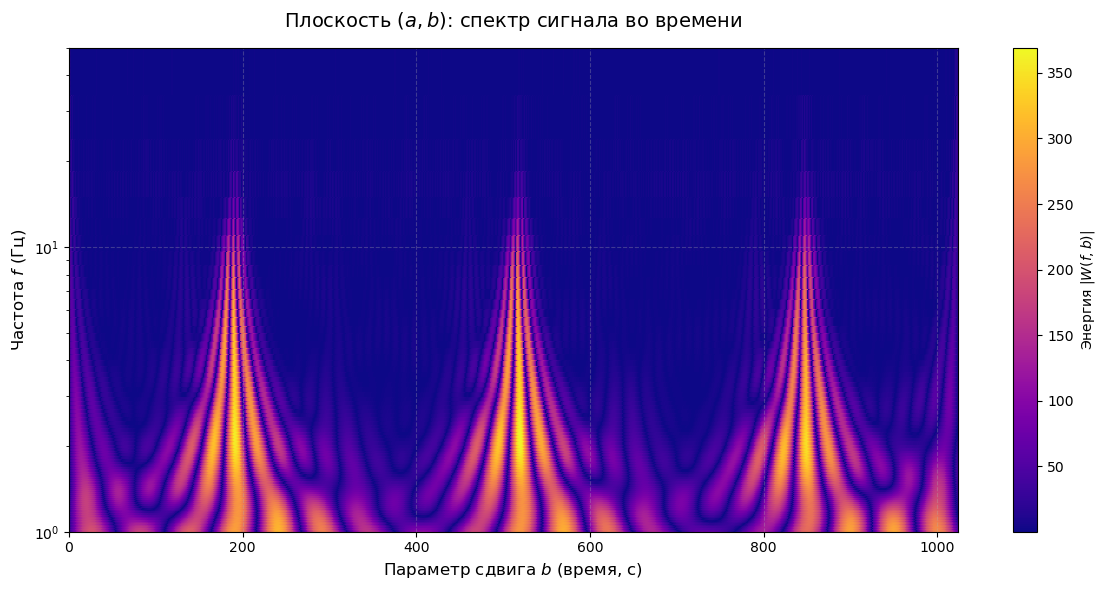

In [13]:
fs = 100.0
central_freq = pywt.central_frequency(wavelet)
freq_axis = central_freq * fs / scales

plt.figure(figsize=(12, 6))
plt.pcolormesh(t, freq_axis, np.abs(coefficients), 
               shading='auto', cmap='plasma', edgecolors='face')

plt.xlabel('Параметр сдвига $b$ (время, с)', fontsize=12)
plt.ylabel('Частота $f$ (Гц)', fontsize=12)
plt.title('Плоскость $(a, b)$: спектр сигнала во времени', fontsize=14, pad=15)

cbar = plt.colorbar(label='Энергия $|W(f,b)|$')
cbar.ax.tick_params(labelsize=10)

plt.yscale('log')
plt.ylim(1, fs/2)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

- Построить сечения вейвлет-спектра $W(a,b)$ по нескольким произвольным значениям $a$ и $b$. 

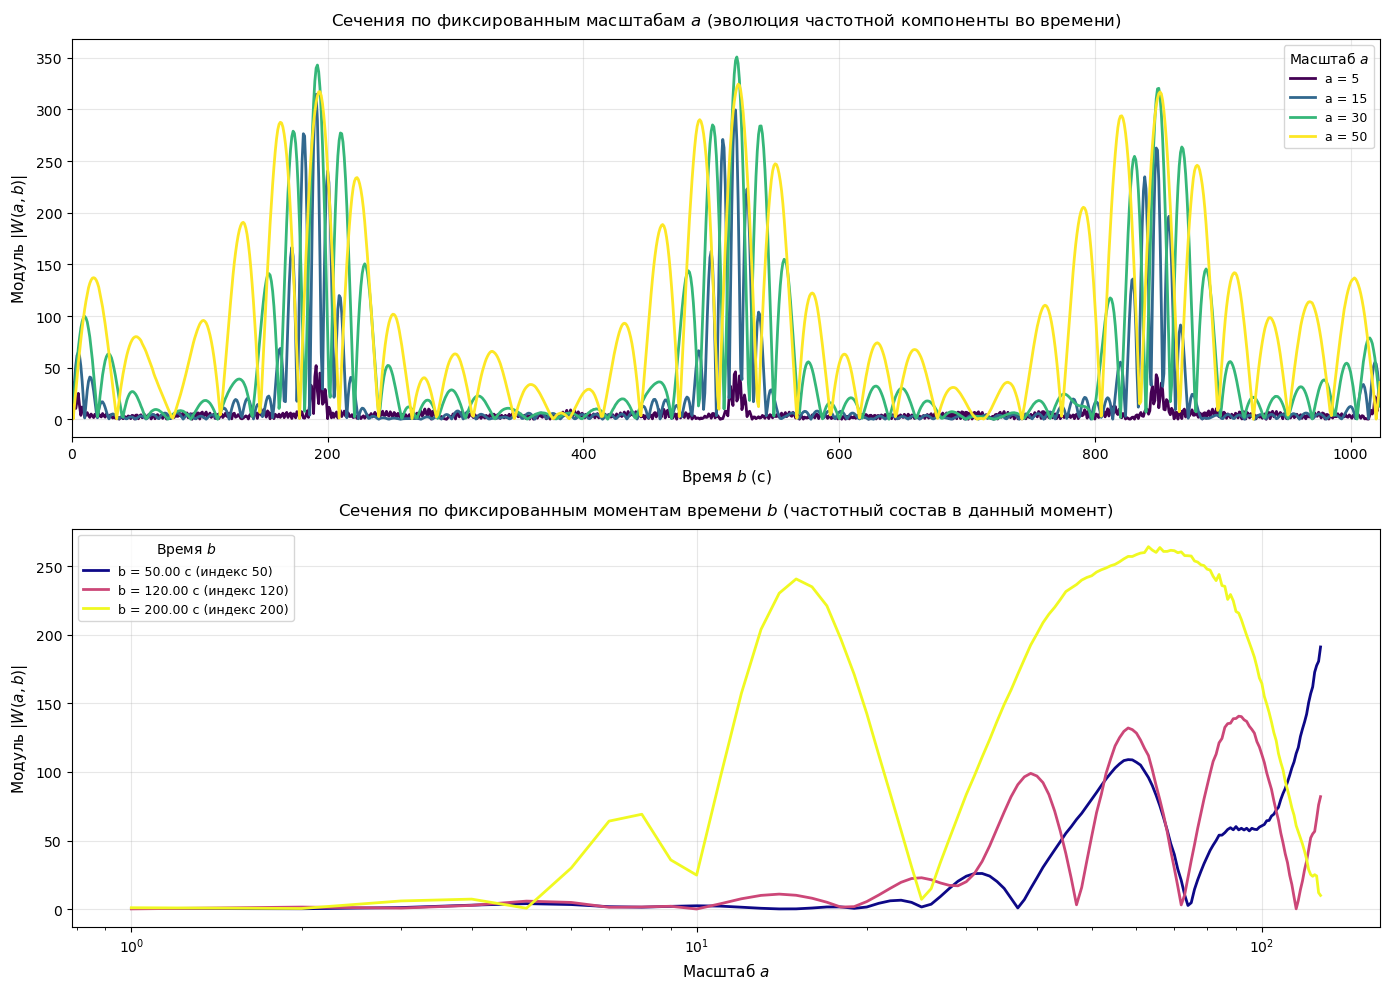

In [ ]:
N = len(signal)
a_values = [5, 15, 30, 50]
b_indices = [50, 120, 200]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]
colors_a = plt.cm.viridis(np.linspace(0, 1, len(a_values)))
for a, color in zip(a_values, colors_a):
    idx = np.argmin(np.abs(scales - a))
    ax1.plot(t, np.abs(coefficients[idx, :]), color=color, linewidth=2, label=f'a = {scales[idx]}')
ax1.set_xlabel('Время $b$ (с)', fontsize=11)
ax1.set_ylabel('Модуль $|W(a,b)|$', fontsize=11)
ax1.set_title('Сечения по фиксированным масштабам $a$ (эволюция частотной компоненты во времени)', fontsize=12, pad=10)
ax1.legend(title='Масштаб $a$', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(t[0], t[-1])

ax2 = axes[1]
colors_b = plt.cm.plasma(np.linspace(0, 1, len(b_indices)))
for b_idx, color in zip(b_indices, colors_b):
    if 0 <= b_idx < N:
        ax2.plot(scales, np.abs(coefficients[:, b_idx]), color=color, linewidth=2, 
                 label=f'b = {t[b_idx]:.2f} с (индекс {b_idx})')
ax2.set_xlabel('Масштаб $a$', fontsize=11)
ax2.set_ylabel('Модуль $|W(a,b)|$', fontsize=11)
ax2.set_title('Сечения по фиксированным моментам времени $b$ (частотный состав в данный момент)', fontsize=12, pad=10)
ax2.legend(title='Время $b$', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

- Построить скелетон - линии локальных экстремумов.

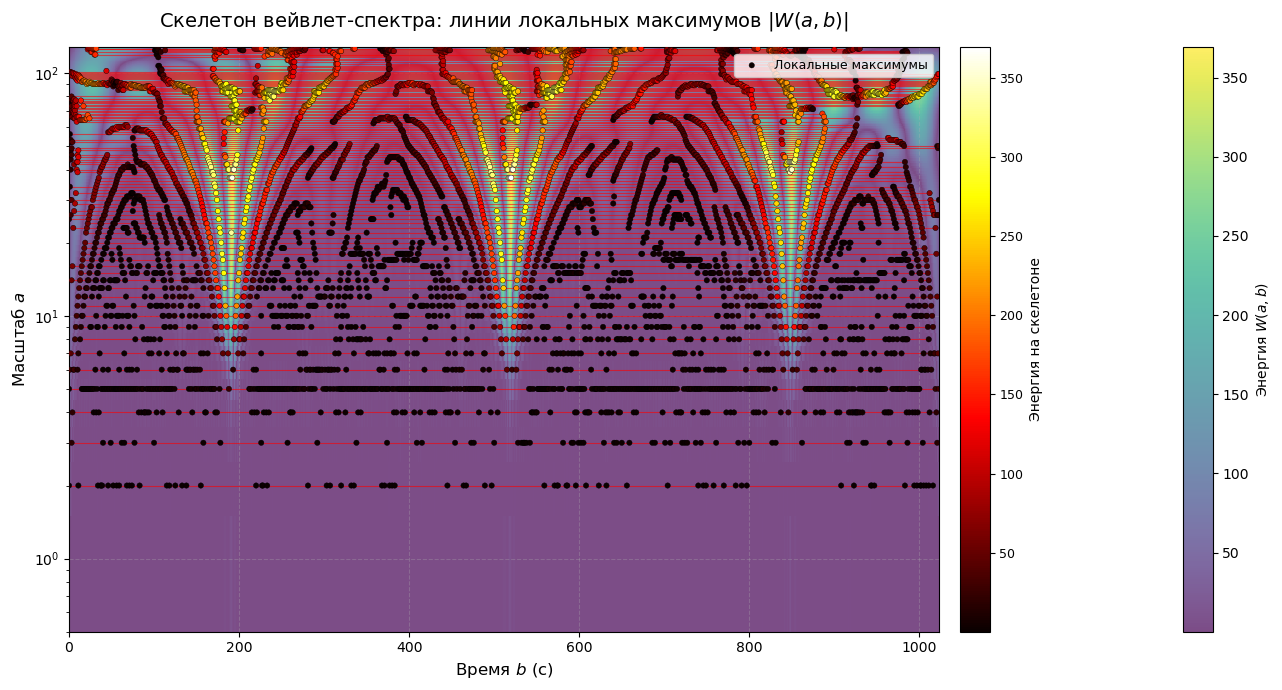

In [19]:
from scipy.signal import argrelextrema

magnitude = np.abs(coefficients)

skeleton_lines = []

for time_idx in range(N):
    profile = magnitude[:, time_idx]
    
    local_max_idx = argrelextrema(profile, np.greater, order=2)[0]
    
    for scale_idx in local_max_idx:
        if 0 < scale_idx < len(scales) - 1:
            skeleton_lines.append((t[time_idx], scales[scale_idx], magnitude[scale_idx, time_idx]))

if skeleton_lines:
    skeleton = np.array(skeleton_lines)
    sk_time, sk_scale, sk_value = skeleton[:, 0], skeleton[:, 1], skeleton[:, 2]
else:
    sk_time, sk_scale, sk_value = np.array([]), np.array([]), np.array([])

fig, ax = plt.subplots(1, 1, figsize=(14, 7))

im = ax.pcolormesh(t, scales, magnitude, shading='auto', cmap='viridis', alpha=0.7)
ax.set_xlabel('Время $b$ (с)', fontsize=12)
ax.set_ylabel('Масштаб $a$', fontsize=12)
ax.set_title('Скелетон вейвлет-спектра: линии локальных максимумов $|W(a,b)|$', fontsize=14, pad=15)
ax.set_yscale('log')

cbar = plt.colorbar(im, ax=ax, label='Энергия $W(a,b)$')
cbar.ax.tick_params(labelsize=10)

if len(sk_time) > 0:
    sc = ax.scatter(sk_time, sk_scale, c=sk_value, s=15, cmap='hot', 
                    edgecolors='black', linewidth=0.3, label='Локальные максимумы', zorder=5)
    cbar_sk = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, label='Энергия на скелетоне')
    cbar_sk.ax.tick_params(labelsize=9)

unique_scales = np.unique(np.round(sk_scale, decimals=1))
for s in unique_scales:
    mask = np.abs(sk_scale - s) < 0.5
    if np.sum(mask) > 3:
        idx = np.argsort(sk_time[mask])
        ax.plot(sk_time[mask][idx], sk_scale[mask][idx], 'r-', linewidth=0.8, alpha=0.6)

ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()